# Phase 1 — Exploratory Data Analysis & Time-Based Split

**Goal:** Understand the Sparkov fraud transaction dataset and create a leakage-safe chronological train/test split.  
**No model training in this notebook.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Load Data

In [2]:
# Load both CSV files and concatenate into a single dataframe
train_raw = pd.read_csv("../data/fraudTrain.csv")
test_raw = pd.read_csv("../data/fraudTest.csv")

df = pd.concat([train_raw, test_raw], ignore_index=True)
print(f"Combined dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  fraudTrain.csv : {len(train_raw):,} rows")
print(f"  fraudTest.csv  : {len(test_raw):,} rows")

Combined dataset: 1,852,394 rows x 23 columns
  fraudTrain.csv : 1,296,675 rows
  fraudTest.csv  : 555,719 rows


## 2. Column Overview

In [3]:
print("Columns and dtypes:")
print("-" * 45)
for col in df.columns:
    print(f"  {col:<25s} {str(df[col].dtype)}")
print(f"\nShape: {df.shape}")
df.head(3)

Columns and dtypes:
---------------------------------------------
  Unnamed: 0                int64
  trans_date_trans_time     object
  cc_num                    int64
  merchant                  object
  category                  object
  amt                       float64
  first                     object
  last                      object
  gender                    object
  street                    object
  city                      object
  state                     object
  zip                       int64
  lat                       float64
  long                      float64
  city_pop                  int64
  job                       object
  dob                       object
  trans_num                 object
  unix_time                 int64
  merch_lat                 float64
  merch_long                float64
  is_fraud                  int64

Shape: (1852394, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


## 3. Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_df.to_string())
print(f"\nTotal missing values: {missing.sum()}")

                       missing_count  missing_pct
Unnamed: 0                         0          0.0
trans_date_trans_time              0          0.0
cc_num                             0          0.0
merchant                           0          0.0
category                           0          0.0
amt                                0          0.0
first                              0          0.0
last                               0          0.0
gender                             0          0.0
street                             0          0.0
city                               0          0.0
state                              0          0.0
zip                                0          0.0
lat                                0          0.0
long                               0          0.0
city_pop                           0          0.0
job                                0          0.0
dob                                0          0.0
trans_num                          0          0.0


## 4. Target Class Imbalance & Fraud Rate

Legitimate : 1,842,743
Fraudulent : 9,651
Fraud rate : 0.52%


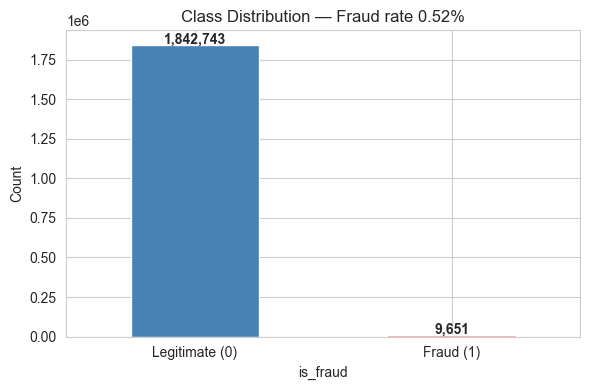

In [5]:
fraud_counts = df["is_fraud"].value_counts()
fraud_rate = df["is_fraud"].mean() * 100

print(f"Legitimate : {fraud_counts[0]:,}")
print(f"Fraudulent : {fraud_counts[1]:,}")
print(f"Fraud rate : {fraud_rate:.2f}%")

fig, ax = plt.subplots(figsize=(6, 4))
fraud_counts.plot.bar(ax=ax, color=["steelblue", "salmon"])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Class Distribution — Fraud rate {fraud_rate:.2f}%")
for i, v in enumerate(fraud_counts):
    ax.text(i, v + len(df) * 0.005, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

The dataset is heavily imbalanced (~0.5% fraud). This rules out accuracy as a metric — we will use PR-AUC in later phases.

## 5. Transaction Amount Distribution

count    1.852394e+06
mean     7.006357e+01
std      1.592540e+02
min      1.000000e+00
25%      9.640000e+00
50%      4.745000e+01
75%      8.310000e+01
max      2.894890e+04


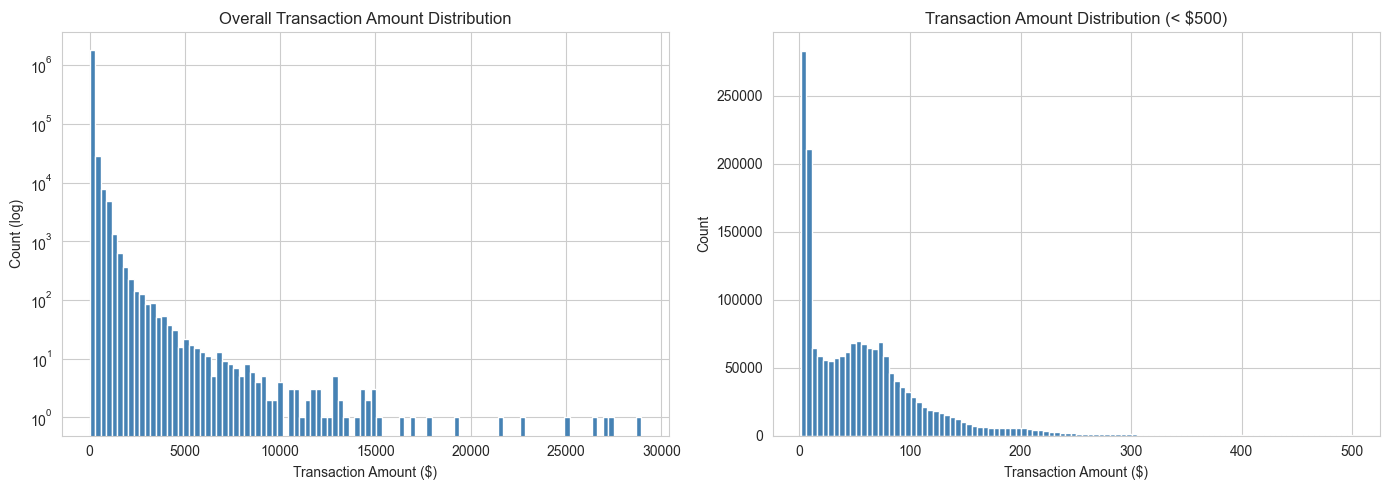

In [6]:
print(df["amt"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution (log scale)
axes[0].hist(df["amt"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Count (log)")
axes[0].set_title("Overall Transaction Amount Distribution")

# Zoomed in (< $500)
axes[1].hist(df.loc[df["amt"] < 500, "amt"], bins=100, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Transaction Amount ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Transaction Amount Distribution (< $500)")

plt.tight_layout()
plt.show()

## 6. Fraud vs Non-Fraud Amount Distribution

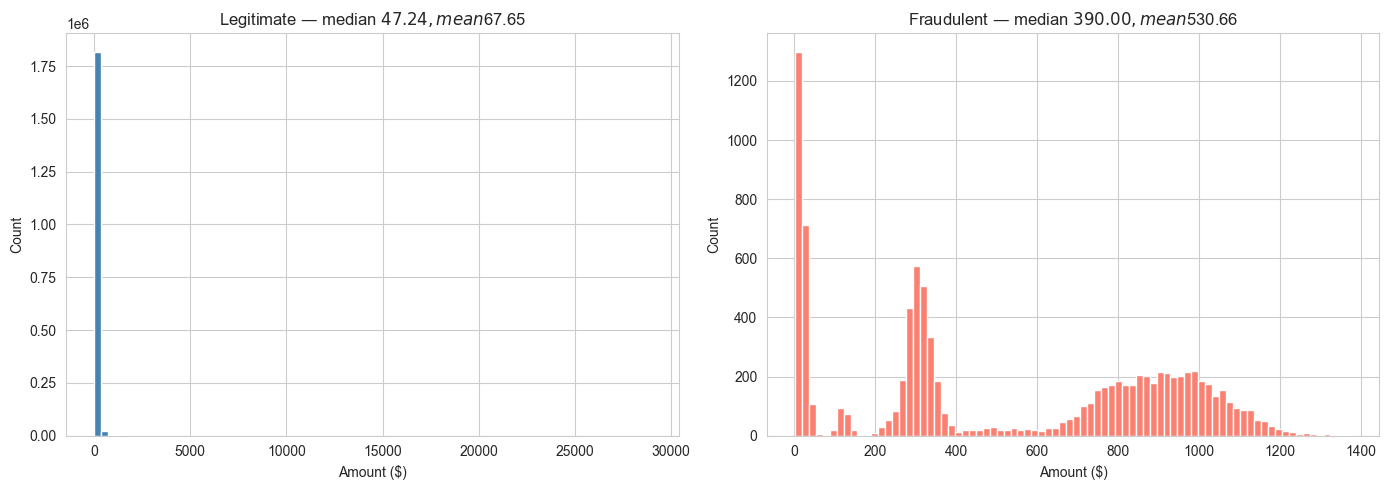

Metric                 Legitimate        Fraud
----------------------------------------------
mean                        67.65       530.66
median                      47.24       390.00
std                        153.55       391.03
min                          1.00         1.06
max                      28948.90      1376.04


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, ax in [(0, "steelblue", axes[0]), (1, "salmon", axes[1])]:
    subset = df.loc[df["is_fraud"] == label, "amt"]
    ax.hist(subset, bins=80, color=color, edgecolor="white")
    ax.set_xlabel("Amount ($)")
    ax.set_ylabel("Count")
    title = "Legitimate" if label == 0 else "Fraudulent"
    ax.set_title(f"{title} — median ${subset.median():.2f}, mean ${subset.mean():.2f}")

plt.tight_layout()
plt.show()

# Side-by-side stats
print(f"{'Metric':<20s} {'Legitimate':>12s} {'Fraud':>12s}")
print("-" * 46)
for stat in ["mean", "median", "std", "min", "max"]:
    leg = getattr(df.loc[df["is_fraud"] == 0, "amt"], stat)()
    fra = getattr(df.loc[df["is_fraud"] == 1, "amt"], stat)()
    print(f"{stat:<20s} {leg:>12.2f} {fra:>12.2f}")

Fraudulent transactions tend to have significantly higher amounts than legitimate ones. This makes `amt` a strong candidate feature.

## 7. Date/Time Range & Parsing

In [8]:
# Parse transaction datetime
df["trans_dt"] = pd.to_datetime(df["trans_date_trans_time"])

print(f"Earliest transaction : {df['trans_dt'].min()}")
print(f"Latest transaction   : {df['trans_dt'].max()}")
print(f"Time span            : {df['trans_dt'].max() - df['trans_dt'].min()}")

Earliest transaction : 2019-01-01 00:00:18
Latest transaction   : 2020-12-31 23:59:34
Time span            : 730 days 23:59:16


## 8. Fraud Rate by Hour of Day

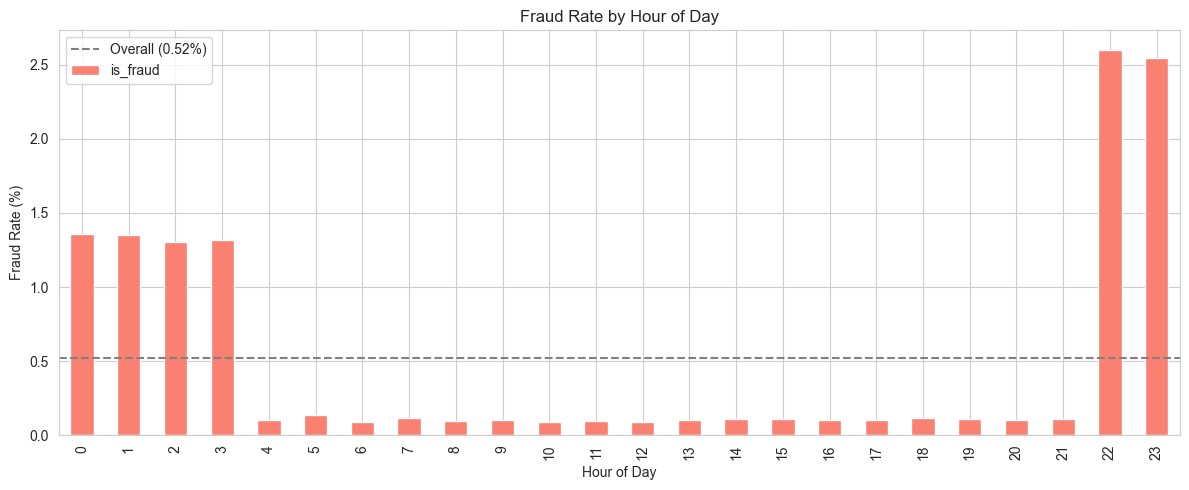

Top 5 hours by fraud rate:
hour
22    2.601447
23    2.546349
0     1.356854
1     1.348443
3     1.317084


In [9]:
df["hour"] = df["trans_dt"].dt.hour
fraud_by_hour = df.groupby("hour")["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
fraud_by_hour.plot.bar(ax=ax, color="salmon", edgecolor="white")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Hour of Day")
ax.axhline(y=fraud_rate, color="gray", linestyle="--", label=f"Overall ({fraud_rate:.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 hours by fraud rate:")
print(fraud_by_hour.sort_values(ascending=False).head().to_string())

Fraud is concentrated in late-night / early-morning hours (roughly 22:00–03:00) when legitimate transaction volume is low. Hour of day will be a useful feature.

## 9. Fraud Rate by Category

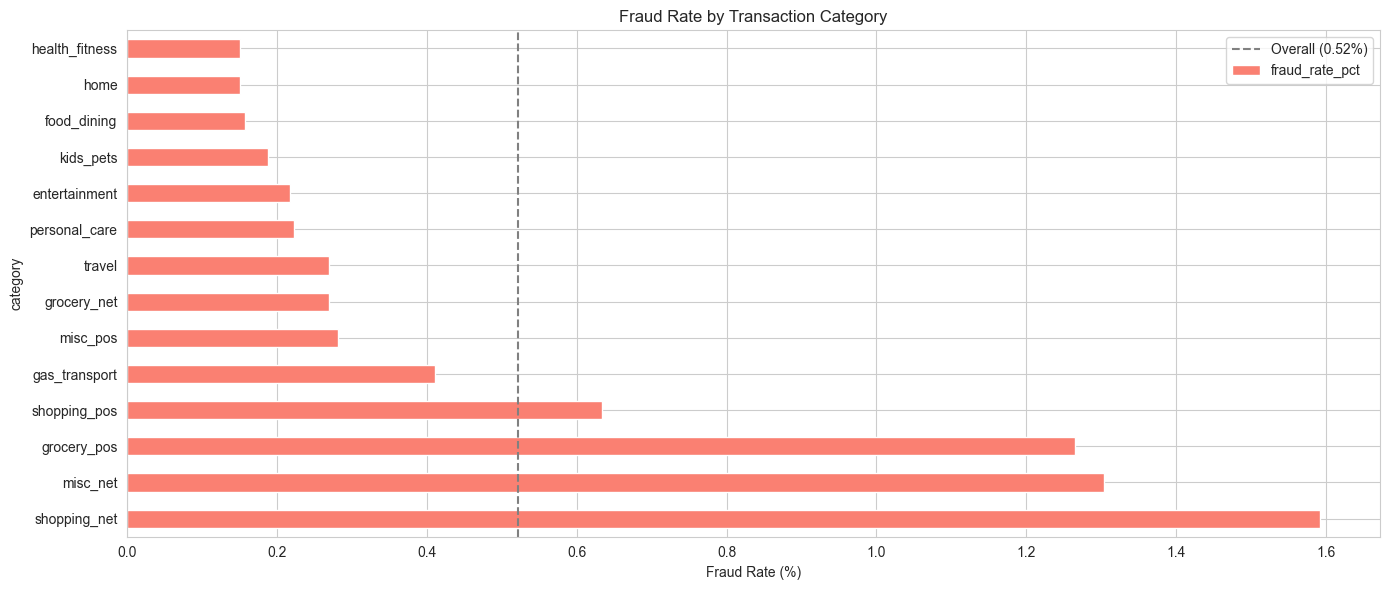

                fraud_rate_pct  n_transactions
category                                      
shopping_net          1.592713          139322
misc_net              1.303859           90654
grocery_pos           1.264537          176191
shopping_pos          0.634375          166463
gas_transport         0.410575          188029
misc_pos              0.281890          114229
grocery_net           0.269737           64878
travel                0.269170           57956
personal_care         0.222931          130085
entertainment         0.217719          134118
kids_pets             0.187971          161727
food_dining           0.156813          130729
home                  0.151032          175460
health_fitness        0.150955          122553


In [10]:
fraud_by_cat = df.groupby("category")["is_fraud"].agg(["mean", "count"]).rename(
    columns={"mean": "fraud_rate", "count": "n_transactions"}
)
fraud_by_cat["fraud_rate_pct"] = fraud_by_cat["fraud_rate"] * 100
fraud_by_cat = fraud_by_cat.sort_values("fraud_rate", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fraud_by_cat["fraud_rate_pct"].plot.barh(ax=ax, color="salmon", edgecolor="white")
ax.set_xlabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Transaction Category")
ax.axvline(x=fraud_rate, color="gray", linestyle="--", label=f"Overall ({fraud_rate:.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()

print(fraud_by_cat[["fraud_rate_pct", "n_transactions"]].to_string())

## 10. Fraud Rate by Merchant (Top 20)

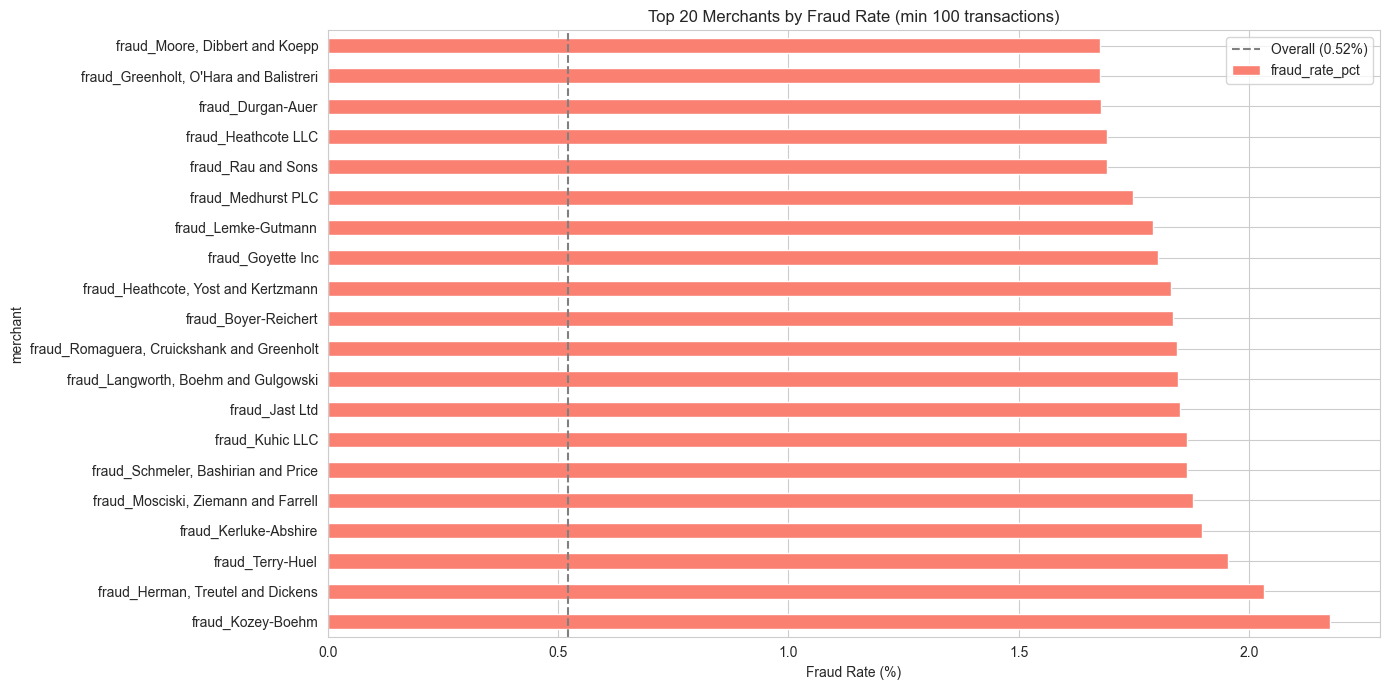

Total unique merchants: 693
Merchants with ≥100 txns: 693


In [11]:
# Focus on merchants with at least 100 transactions to avoid noise
merchant_stats = df.groupby("merchant")["is_fraud"].agg(["mean", "count"]).rename(
    columns={"mean": "fraud_rate", "count": "n_transactions"}
)
merchant_stats = merchant_stats[merchant_stats["n_transactions"] >= 100]
merchant_stats["fraud_rate_pct"] = merchant_stats["fraud_rate"] * 100
top20_merchants = merchant_stats.sort_values("fraud_rate", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
top20_merchants["fraud_rate_pct"].plot.barh(ax=ax, color="salmon", edgecolor="white")
ax.set_xlabel("Fraud Rate (%)")
ax.set_title("Top 20 Merchants by Fraud Rate (min 100 transactions)")
ax.axvline(x=fraud_rate, color="gray", linestyle="--", label=f"Overall ({fraud_rate:.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total unique merchants: {df['merchant'].nunique():,}")
print(f"Merchants with ≥100 txns: {len(merchant_stats):,}")

---

## 11. Leakage-Safe Time-Based Train/Test Split

We sort all transactions chronologically and take the first 80% for training and the last 20% for testing. This prevents data leakage from future transactions into the training set.

In [12]:
# Sort by transaction datetime
df_sorted = df.sort_values("trans_dt").reset_index(drop=True)

# 80/20 chronological split
split_idx = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

print(f"Split index: {split_idx:,}")
print(f"Train: {len(train):,} rows | Test: {len(test):,} rows")

Split index: 1,481,915
Train: 1,481,915 rows | Test: 370,479 rows


In [13]:
# Summary statistics for the split
train_fraud = train["is_fraud"].sum()
test_fraud = test["is_fraud"].sum()
train_legit = len(train) - train_fraud
test_legit = len(test) - test_fraud

print("=" * 55)
print("         TIME-BASED SPLIT SUMMARY")
print("=" * 55)
print(f"{'Metric':<30s} {'Train':>12s} {'Test':>12s}")
print("-" * 55)
print(f"{'Shape':<30s} {str(train.shape):>12s} {str(test.shape):>12s}")
print(f"{'Date range start':<30s} {str(train['trans_dt'].min().date()):>12s} {str(test['trans_dt'].min().date()):>12s}")
print(f"{'Date range end':<30s} {str(train['trans_dt'].max().date()):>12s} {str(test['trans_dt'].max().date()):>12s}")
print(f"{'Fraud count':<30s} {train_fraud:>12,} {test_fraud:>12,}")
print(f"{'Legitimate count':<30s} {train_legit:>12,} {test_legit:>12,}")
print(f"{'Fraud rate':<30s} {train['is_fraud'].mean()*100:>11.2f}% {test['is_fraud'].mean()*100:>11.2f}%")
print("=" * 55)

# Confirm no temporal leakage
assert train["trans_dt"].max() <= test["trans_dt"].min(), "Temporal leakage detected!"
print("\n✅ No temporal leakage — train ends before test begins.")

         TIME-BASED SPLIT SUMMARY
Metric                                Train         Test
-------------------------------------------------------
Shape                          (1481915, 25) (370479, 25)
Date range start                 2019-01-01   2020-08-25
Date range end                   2020-08-25   2020-12-31
Fraud count                           8,302        1,349
Legitimate count                  1,473,613      369,130
Fraud rate                            0.56%        0.36%

✅ No temporal leakage — train ends before test begins.


## 12. Save Split Files

In [14]:
import os

out_dir = "../data/processed"
os.makedirs(out_dir, exist_ok=True)

# Drop the helper columns before saving
train_out = train.drop(columns=["trans_dt", "hour"])
test_out = test.drop(columns=["trans_dt", "hour"])

train_out.to_csv(os.path.join(out_dir, "train_time_split.csv"), index=False)
test_out.to_csv(os.path.join(out_dir, "test_time_split.csv"), index=False)

print(f"✅ Saved train_time_split.csv  ({len(train_out):,} rows)")
print(f"✅ Saved test_time_split.csv   ({len(test_out):,} rows)")

✅ Saved train_time_split.csv  (1,481,915 rows)
✅ Saved test_time_split.csv   (370,479 rows)


---

## Summary of EDA Findings

1. **Dataset size:** ~1.85M transactions across 23 columns; no missing values.
2. **Class imbalance:** Only ~0.52% of transactions are fraudulent — heavy imbalance confirms we must avoid accuracy and use ranking metrics (PR-AUC) in later phases.
3. **Transaction amounts:** Fraudulent transactions have substantially higher amounts (higher mean and median) compared to legitimate ones.
4. **Temporal patterns:** Fraud rate spikes during late-night / early-morning hours (22:00–03:00), when overall transaction volume is low.
5. **Category risk:** Categories like `shopping_net` and `grocery_pos` see different fraud rates — category is an informative feature.
6. **Time-based split:** An 80/20 chronological split was created with no temporal leakage. The train set covers earlier dates and the test set covers later dates, simulating a realistic deployment scenario.